In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [4]:
df = pd.read_csv("../data/placement_predict_50k Dataset_final.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 45)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
0,-0.540266,-1.159080,-1.064481,-1.137401,-1.035531,-0.998604,-1.056297,-1.380776,-0.850175,-1.021957,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,-1.215032,-0.277425,0.219222,-0.293950,-0.221499,-0.200163,-0.096825,0.003680,-0.307593,-0.169077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.890055,0.623969,0.545035,0.285520,0.961391,0.686295,0.488827,0.883578,0.326435,0.516936,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.124963,0.637128,0.577616,0.729780,0.204596,0.516547,0.694428,0.545156,0.826342,0.609640,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
4,-0.494443,0.702924,1.085884,0.761973,1.279373,1.063511,1.261389,0.871272,0.960463,1.091703,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [5]:
x = df[[
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]]

y = df["Salary Package"]

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (10000, 5)
Y shape: (10000,)


In [6]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students with Salary Package > 0:", len(placed_df))

Placed students with Salary Package > 0: 3663


In [7]:
x = placed_df[[
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]]

y = placed_df["Salary Package"]

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (3663, 5)
Y shape: (3663,)


In [8]:
x = x.fillna(x.mean())

print("Missing values after preprocessing:")
print(x.isnull().sum())

Missing values after preprocessing:
CGPA                  0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
dtype: int64


In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 2930
Testing samples: 733


In [10]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.4 ,-0.05, 0.11,-0.01, 0.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['CGPA','AptitudeTestScore','SoftSkillsRating','CodingTestScore', 'MockInterviewScore']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6585
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [11]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 0.6584851617050062
Slope: 0.402757892973799


In [12]:
y_train_pred = model.predict(x_train)

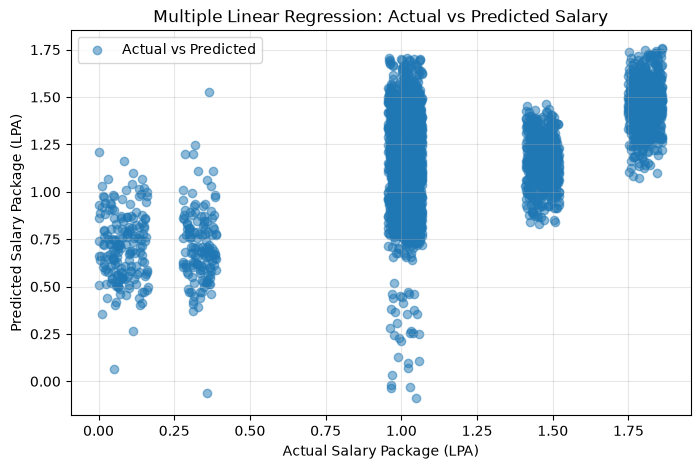

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train,
    y_train_pred,
    alpha=0.5,
    label="Actual vs Predicted"
)

plt.xlabel("Actual Salary Package (LPA)")
plt.ylabel("Predicted Salary Package (LPA)")
plt.title("Multiple Linear Regression: Actual vs Predicted Salary")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
y_test_pred = model.predict(x_test)

In [15]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.13248561258007283
RMSE: 0.363985731286369
MAE : 0.3013218758431832
R²  : 0.34684987313609705


In [16]:
new_student = [[
    float(input("Enter CGPA: ")),
    float(input("Enter Aptitude Test Score: ")),
    float(input("Enter Soft Skills Rating: ")),
    float(input("Enter Coding Test Score: ")),
    float(input("Enter Mock Interview Score: "))
]]

predicted_salary = model.predict(new_student)[0]

print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")

Predicted Salary Package: 28.85 LPA


c:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
